# ML Lab 02 — From Raw Data to ML-Ready Data (Customer Churn EDA)
**Name:** Shahzeb Ali
**Dataset:** Telco Customer Churn (Kaggle, with simulated missing values)

In this lab I am not building any model yet, I am just understanding the data, cleaning it and doing EDA on it so that it is ready for Lab 3.

In [1]:
# importing the libraries I will need for this lab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# so the plots show up nicely in the notebook
%matplotlib inline
sns.set_style('whitegrid')

In [2]:
# loading the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part 1 — The Business Problem

**Task: Business problem in my own words + target variable**

The company (a telecom) is losing customers to other competitors, this is called churn. They want to know which customers are more likely to leave the company so they can try to stop it before it happens (like offer them a discount or a better plan). So basically this is a classification problem where we have to predict if a customer will churn (leave) or not. The target variable is most likely the `Churn` column since it directly tells us Yes/No if the customer left.

**Task: 5 useful predictors and 2 useless predictors**

Columns I think will be useful for predicting churn:
1. `Contract` — people on month-to-month contracts can leave anytime so I think they churn more.
2. `tenure` — how long someone has been a customer, newer customers probably churn more.
3. `MonthlyCharges` — if someone is paying a lot every month they might be more likely to leave.
4. `InternetService` — the type of internet (fiber optic, DSL, none) might affect satisfaction.
5. `PaymentMethod` — automatic payments vs manual ones might show different loyalty levels.

Columns I think will NOT be useful:
1. `customerID` — this is just a random ID for each customer, it has no real predictive meaning.
2. `gender` — I don't think whether someone is male or female should really affect if they leave the company or not.

**Task: 2 questions I want this data to answer**

1. Do customers with longer contracts (1 year / 2 year) actually churn less than month-to-month customers?
2. Does the payment method (like electronic check vs automatic bank transfer) have any relation with churn?

## Part 2 — Exploring the Dataset Structure

In [3]:
# checking the shape of the data - rows and columns
print("Shape of dataset:", df.shape)
print("Number of customers (rows):", df.shape[0])
print("Number of features (columns):", df.shape[1])

Shape of dataset: (7043, 21)
Number of customers (rows): 7043
Number of features (columns): 21


In [4]:
# checking data types of every column
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**Task: numerical vs categorical features**

From `df.dtypes` I can group the columns like this:

- **Numerical features:** `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges` (although `TotalCharges` is showing up as object/string type, not number, which is weird — I will look into that in Part 3).
- **Categorical features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, and the target `Churn`.
- `customerID` doesn't really belong to either group, it's just an identifier.

In [5]:
# looking for identifier columns and columns with a wrong looking dtype
print(df['customerID'].nunique(), "unique values out of", len(df), "rows")
print(df[['SeniorCitizen','TotalCharges']].dtypes)
df[['SeniorCitizen','TotalCharges']].head()

7043 unique values out of 7043 rows
SeniorCitizen    int64
TotalCharges       str
dtype: object


,SeniorCitizen,TotalCharges
0,0,29.85
1,0,1889.5
2,0,108.15
3,0,1840.75
4,0,151.65


**Task: identifier columns / wrong data types**

- `customerID` has as many unique values as there are rows (7043), so it is purely an identifier, it does not carry any predictive information by itself.
- `SeniorCitizen` is stored as an integer (0/1) but it is actually a Yes/No flag, so its dtype looks a bit misleading — it should really be treated as categorical, not numerical.
- `TotalCharges` is stored as an **object (text)** column even though it clearly represents a dollar amount, so this dtype is wrong, it should be a float. This is a strong hint something is hiding inside this column (I check it properly in Part 3).

In [6]:
# picking 3 categorical columns and checking their unique values
print("Contract:", df['Contract'].unique())
print("InternetService:", df['InternetService'].unique())
print("PaymentMethod:", df['PaymentMethod'].unique())

Contract: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
PaymentMethod: <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Task: unexpected/inconsistent categories?**

I checked `Contract`, `InternetService` and `PaymentMethod`. All three look clean to me — no weird capitalization, no typos, no random extra category like `"month-to-month "` with a space or `"DSl"` misspelled. `InternetService` also has a `'No'` category which just means the customer doesn't have internet at all, which makes sense and isn't a data quality issue, just a real category.

## Part 3 — Investigating Data Quality

In [7]:
# checking missing values as count and percentage
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({'missing_count': missing_count, 'missing_percent': missing_percent})
missing_table

,missing_count,missing_percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


**Task: missing values — which need action?**

At first glance `df.isnull().sum()` shows **zero missing values in every single column**, which is surprising because the manual said this dataset has simulated missing values in it. This made me suspicious, so I don't think there really are zero missing values — I think they are probably hidden as blank strings or spaces instead of a real `NaN`, especially since I already noticed `TotalCharges` has the wrong data type. So I decided to dig deeper instead of trusting `isnull()` blindly.

In [8]:
# TotalCharges looked suspicious in Part 2, so I try converting it to numbers
# errors='coerce' will turn anything that can't be converted into NaN
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Number of values that could NOT be converted to numeric:", total_charges_numeric.isnull().sum())

# let's see those rows
df[total_charges_numeric.isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of values that could NOT be converted to numeric: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


So there it is — **11 rows** have a blank/whitespace value in `TotalCharges` instead of an actual number. `isnull()` didn't catch these because technically they are not `NaN`, they are just empty-looking strings, so this was a hidden missing value problem. This one definitely needs action because we can't do any math (like correlation or modeling) on a text column.

I also noticed something interesting: every single one of these 11 rows has `tenure = 0`, meaning these are brand new customers who literally just joined and haven't been billed yet, so it actually makes sense that they don't have a total charge amount recorded.

In [9]:
# checking duplicate rows and duplicate customer IDs separately
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID values:", df['customerID'].duplicated().sum())

Fully duplicated rows: 0
Duplicated customerID values: 0


**Task: duplicates — same issue or different?**

There are **0 fully duplicated rows** and **0 duplicated customer IDs**, so luckily this dataset doesn't have a duplicates problem. But I want to note that these two checks are actually different things even though they gave the same answer here: a duplicated *row* means the whole record repeats exactly, while a duplicated *customerID* would mean the same customer appears twice even if some of their other details changed (like an updated plan). Since both are zero we don't need to do anything for this part, but if they weren't both zero I would treat them differently — duplicate IDs would be a bigger problem because it means we might be double counting an actual person.

In [10]:
# looking for suspicious / invalid values in other columns, just to be safe
print(df['SeniorCitizen'].unique())
print(df['tenure'].min(), df['tenure'].max())
print(df['MonthlyCharges'].min(), df['MonthlyCharges'].max())

[0 1]
0 72
18.25 118.75


**Task: another suspicious value found**

I also checked `tenure` and `MonthlyCharges` for anything weird like negative numbers, but their min/max values look reasonable (tenure between 0 and 72 months, monthly charges between about \$18 and \$119). So the main data quality issue I actually found in this dataset is the hidden blank values in `TotalCharges`, and how I found it was by trying to convert the column to numeric type and seeing what broke.

## Part 4 — Data Cleaning Decisions

**Task: Problem → Decision → Method → Reason table**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text, 11 blank values | Convert to numeric, then fill the 11 blanks with 0 | `pd.to_numeric(errors='coerce')` then `.fillna(0)` | All 11 blank rows have `tenure = 0`, meaning these are brand new customers who have not been billed yet, so a total charge of \$0 is logically correct, not a guess. |
| `SeniorCitizen` stored as 0/1 integer but is really a category | Map to `'No'`/`'Yes'` so it matches the style of the other Yes/No columns | `.map({0:'No', 1:'Yes'})` | Keeping it numeric makes it easy to accidentally treat it as if "1.5 senior citizens" made sense, converting it to Yes/No makes its true categorical nature clear and consistent with columns like `Partner`. |
| `customerID` is a pure identifier | Keep it for now (needed to trace rows), but flag it for removal before modeling | none yet, just noted for Part 10/11 | It carries no real predictive signal, it's basically a random string, so it shouldn't be fed to a model. |
| Possible duplicate rows/IDs | No action needed | `df.duplicated().sum()` confirmed 0 | Already checked in Part 3 — nothing to clean here. |

I am not touching any of the other columns because I did not find a real problem with them — I don't want to "clean" something that isn't broken.

In [11]:
# applying my cleaning decisions to build an intermediate cleaned dataframe
df_clean = df.copy()

# 1) fix TotalCharges: convert to numeric, then fill the 11 new-customer blanks with 0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 2) turn SeniorCitizen into Yes/No so it matches the other categorical columns
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# confirming with code that each issue is actually resolved
print("TotalCharges dtype now:", df_clean['TotalCharges'].dtype)
print("Missing values left in TotalCharges:", df_clean['TotalCharges'].isnull().sum())
print("SeniorCitizen unique values now:", df_clean['SeniorCitizen'].unique())
print("Duplicate rows:", df_clean.duplicated().sum())

TotalCharges dtype now: float64
Missing values left in TotalCharges: 0
SeniorCitizen unique values now: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Duplicate rows: 0


All good — `TotalCharges` is now a proper float column with no missing values, `SeniorCitizen` reads as Yes/No like the rest of the categorical columns, and there are still no duplicates. I will keep using `df_clean` from now on for the rest of the lab.

## Part 5 — Univariate EDA

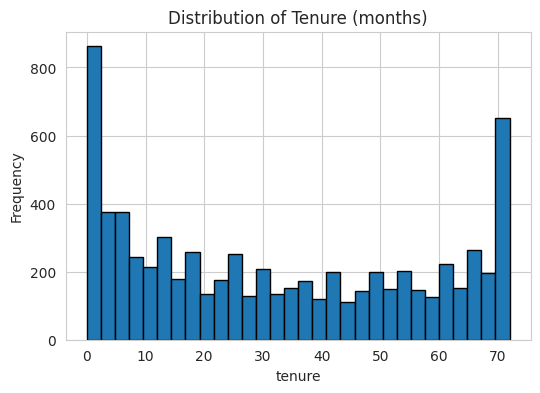

In [13]:
# Numerical feature 1: tenure
plt.figure(figsize=(6,4))
df_clean['tenure'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of Tenure (months)')
plt.xlabel('tenure')
plt.show()

**What I learned:** the `tenure` distribution is not really a normal bell curve, there's a huge spike of customers at very low tenure (close to 0) and another smaller bump near 72 months (the max). This makes me think there's a mix of brand-new customers and a group of very loyal long-term customers, with fewer people in between.

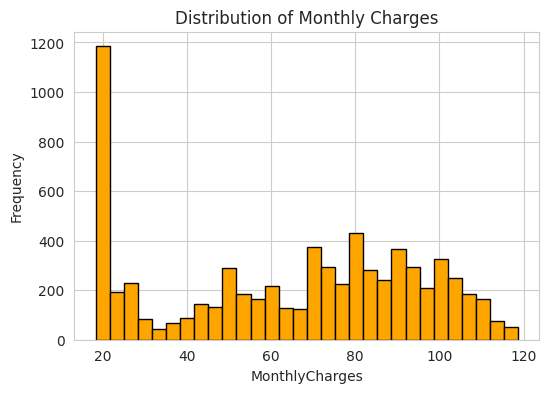

In [14]:
# Numerical feature 2: MonthlyCharges
plt.figure(figsize=(6,4))
df_clean['MonthlyCharges'].plot(kind='hist', bins=30, edgecolor='black', color='orange')
plt.title('Distribution of Monthly Charges')
plt.xlabel('MonthlyCharges')
plt.show()

**What I learned:** `MonthlyCharges` looks kind of bimodal — a big group of customers pay around \$20 (probably the ones with no internet, just phone service) and then another spread of customers paying somewhere between \$70-\$100 (probably the ones with internet + extra services).

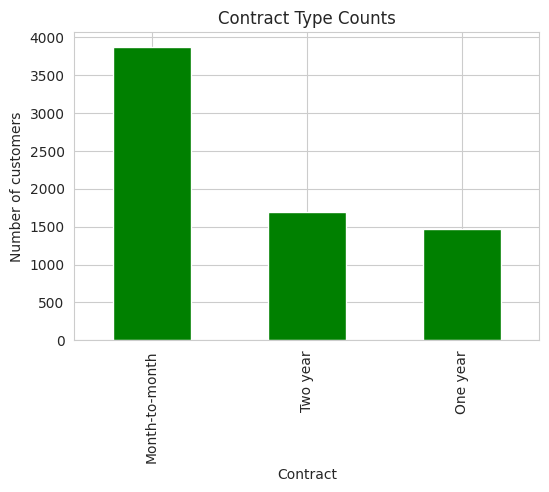

In [15]:
# Categorical feature 1: Contract
plt.figure(figsize=(6,4))
df_clean['Contract'].value_counts().plot(kind='bar', color='green')
plt.title('Contract Type Counts')
plt.xlabel('Contract')
plt.ylabel('Number of customers')
plt.show()

**What I learned:** most customers are on a `Month-to-month` contract, way more than `One year` or `Two year` combined. This is important because month-to-month customers are probably the easiest ones to lose since they aren't locked in.

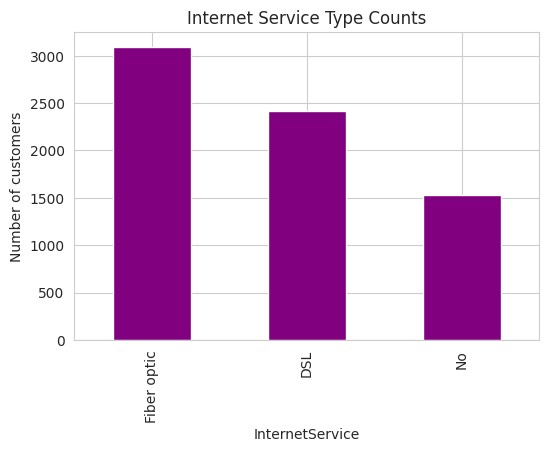

In [16]:
# Categorical feature 2: InternetService
plt.figure(figsize=(6,4))
df_clean['InternetService'].value_counts().plot(kind='bar', color='purple')
plt.title('Internet Service Type Counts')
plt.xlabel('InternetService')
plt.ylabel('Number of customers')
plt.show()

**What I learned:** `Fiber optic` is the most common internet type, followed by `DSL`, and then customers with `No` internet service at all. Since fiber optic is usually the pricier plan this probably connects with the higher-charges group I saw in the `MonthlyCharges` histogram.

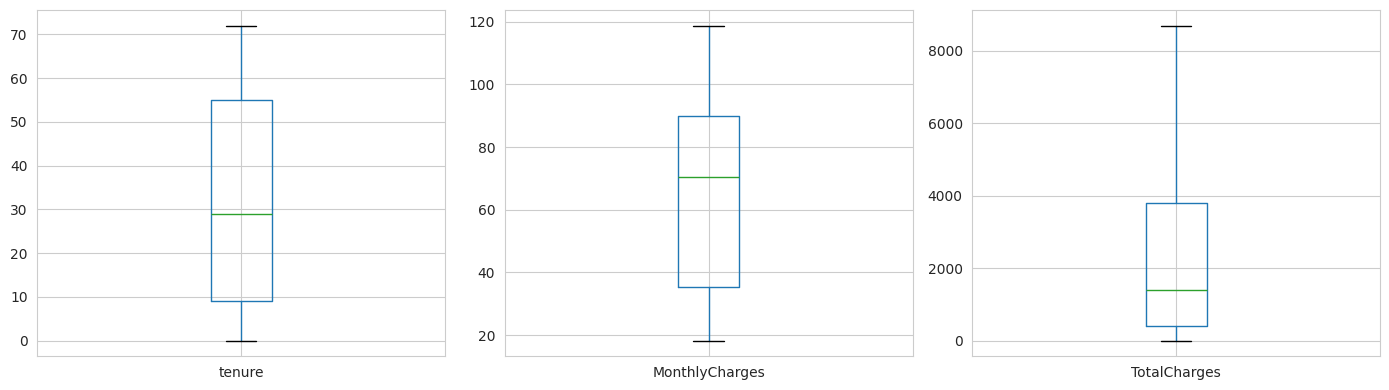

In [17]:
# checking for outliers using boxplots on the numerical features
fig, axes = plt.subplots(1, 3, figsize=(14,4))
df_clean.boxplot(column='tenure', ax=axes[0])
df_clean.boxplot(column='MonthlyCharges', ax=axes[1])
df_clean.boxplot(column='TotalCharges', ax=axes[2])
plt.tight_layout()
plt.show()

**Task: outliers or skewed distributions?**

`tenure` and `MonthlyCharges` don't really have extreme outliers in the boxplot, they're just spread out / a bit bimodal like I said above. `TotalCharges` on the other hand is clearly **right-skewed**, with most customers having a low total charge and a long tail going up to very high values. This makes sense though — `TotalCharges` basically builds up the longer someone stays a customer, so long-tenure customers naturally accumulate a much bigger total, this isn't really a "bad" outlier, it's just how the value is expected to grow over time.

## Part 6 — Target Variable Analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


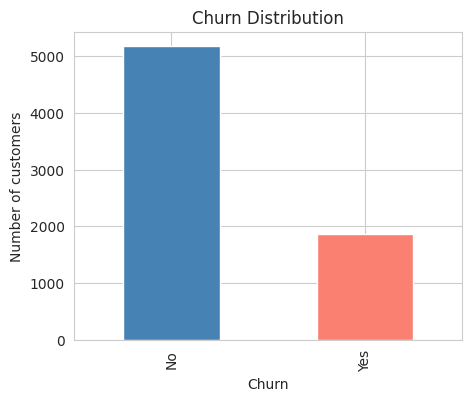

In [18]:
# churn counts and percentages
churn_counts = df_clean['Churn'].value_counts()
churn_percent = df_clean['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percent.round(2))

plt.figure(figsize=(5,4))
df_clean['Churn'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.show()

**Task: balanced or imbalanced?**

Out of 7043 customers, **5174 (about 73.5%) did NOT churn** and **1869 (about 26.5%) DID churn**. So the target is clearly **imbalanced**, roughly a 3-to-1 ratio, not anywhere close to 50/50.

**Task: why does imbalance matter for a later model?**

If a model is trained on this data and just learns to always predict "No churn", it would already be right about 73.5% of the time just by chance, which sounds good but is actually useless since it never catches the customers who are about to leave. So accuracy alone would be a misleading metric here, and the model might end up biased toward the majority class unless we use other metrics (like precision, recall, F1) or techniques to handle the imbalance when we get to modeling in Lab 3.

## Part 7 — Bivariate Analysis: Features vs. Churn

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


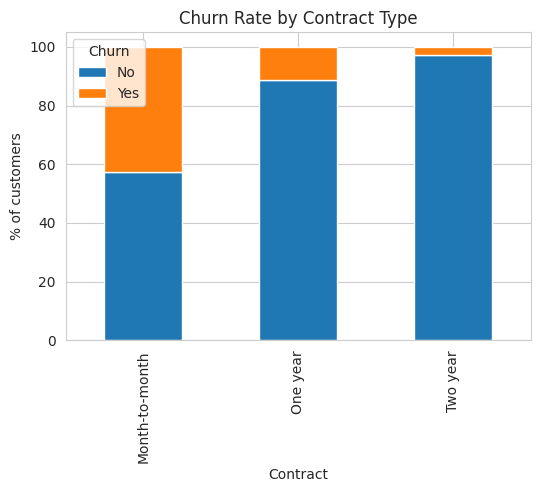

In [19]:
# Categorical feature 1: Contract vs Churn
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(contract_churn.round(2))

contract_churn.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Churn Rate by Contract Type')
plt.ylabel('% of customers')
plt.show()

**Contract vs Churn**
- **Observation:** Churn rate drops massively as contract length increases.
- **Evidence:** Month-to-month churn is about 42.7%, One year is about 11.3%, and Two year is only about 2.8%.
- **Possible Explanation:** Customers on longer contracts have basically committed/locked themselves in, so they can't just leave whenever, while month-to-month customers have full freedom to switch companies at any time, so naturally more of them do.

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


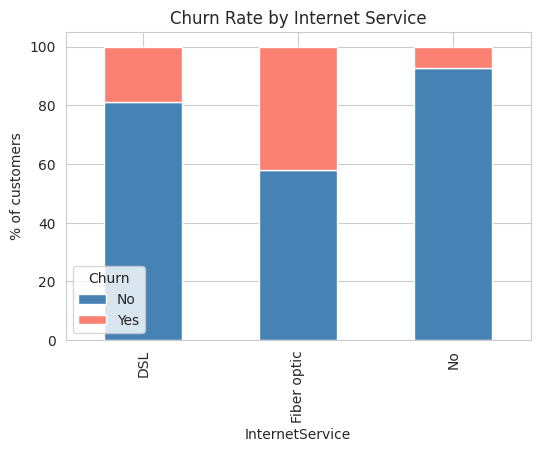

In [20]:
# Categorical feature 2: InternetService vs Churn
internet_churn = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
print(internet_churn.round(2))

internet_churn.plot(kind='bar', stacked=True, figsize=(6,4), color=['steelblue','salmon'])
plt.title('Churn Rate by Internet Service')
plt.ylabel('% of customers')
plt.show()

**InternetService vs Churn**
- **Observation:** Fiber optic customers churn a lot more than DSL or no-internet customers.
- **Evidence:** Fiber optic churn is about 41.9%, DSL is about 19.0%, and No internet is only about 7.4%.
- **Possible Explanation:** Fiber optic is usually the most expensive plan (matches the higher `MonthlyCharges` I saw earlier), so maybe these customers are more price sensitive or maybe they are unhappy with reliability/price and end up leaving more.

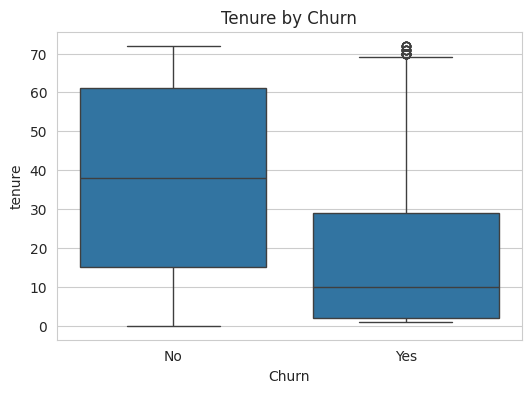

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [21]:
# Numerical feature 1: tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean)
plt.title('Tenure by Churn')
plt.show()

print(df_clean.groupby('Churn')['tenure'].mean())

**tenure vs Churn**
- **Observation:** Customers who churned have a much lower tenure on average.
- **Evidence:** Average tenure for churned customers is about 18 months vs about 37.6 months for customers who stayed, and the boxplot shows the churned group is shifted way lower.
- **Possible Explanation:** Newer customers probably haven't built up loyalty yet or maybe haven't seen enough value from the service, so they're more likely to leave early, while people who already stuck around for years are less likely to suddenly quit.

/tmp/ipykernel_474/4255606025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['steelblue','salmon'])


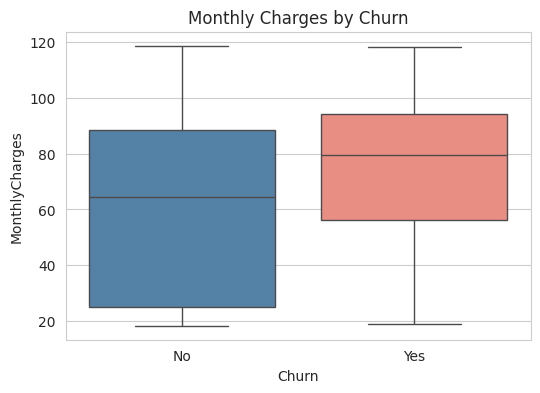

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [22]:
# Numerical feature 2: MonthlyCharges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['steelblue','salmon'])
plt.title('Monthly Charges by Churn')
plt.show()

print(df_clean.groupby('Churn')['MonthlyCharges'].mean())

**MonthlyCharges vs Churn**
- **Observation:** Customers who churned tend to pay higher monthly charges.
- **Evidence:** Average monthly charge for churned customers is about \$74.4 vs about \$61.3 for customers who stayed.
- **Possible Explanation:** This lines up with what I found for `InternetService` — fiber optic customers pay more and churn more, so higher bills might be pushing some customers toward canceling, especially if they don't feel like they're getting good value for the price.

## Part 8 — Correlation & Feature Relationships

In [23]:
# correlation matrix of the numerical features
# (SeniorCitizen is Yes/No now so I use the original 0/1 version just for this numeric check)
numeric_df = df_clean.copy()
numeric_df['SeniorCitizen_num'] = df['SeniorCitizen']  # original 0/1 version

corr_matrix = numeric_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_num']].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen_num
tenure,1.000000,0.247900,0.826178,0.016567
MonthlyCharges,0.247900,1.000000,0.651174,0.220173
TotalCharges,0.826178,0.651174,1.000000,0.103006
SeniorCitizen_num,0.016567,0.220173,0.103006,1.000000


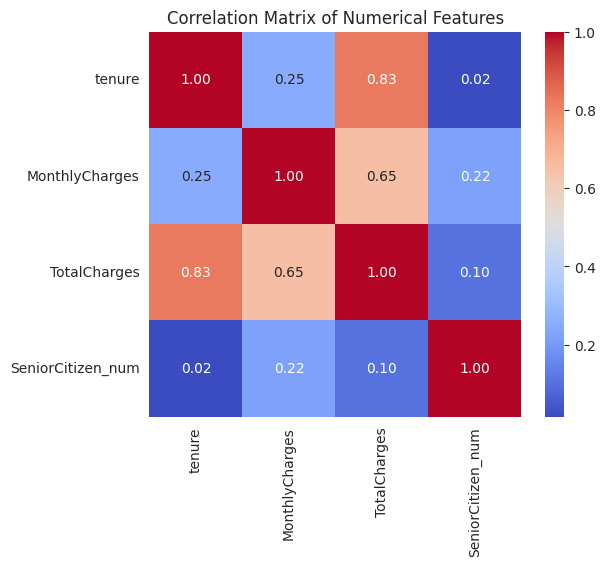

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Task: which pairs are most correlated?**

`TotalCharges` and `tenure` have the strongest correlation by far, about **0.83**. `TotalCharges` and `MonthlyCharges` are also fairly correlated, around **0.65**. This actually makes total sense, `TotalCharges` is basically built up from `tenure × MonthlyCharges` roughly, so it's not really a coincidence, it's almost the same information repeated.

**Task: does correlation imply causation, and could it cause problems later?**

No, correlation doesn't mean causation here — `tenure` and `TotalCharges` being correlated doesn't mean one is "causing" the other in some meaningful business sense, it's more of a mathematical/structural relationship. This could actually cause a problem for a future model though, because having `tenure`, `MonthlyCharges`, and `TotalCharges` all together is kind of redundant since `TotalCharges` doesn't add much new information beyond the other two — this is called multicollinearity, and it can make some models (like linear/logistic regression) less stable or harder to interpret.

## Part 9 — Data Leakage Awareness

**Task: suspects for data leakage**

I went through the columns looking for anything that would only be known *after* a customer already churned, or is just an identifier:

- `customerID` — pure identifier, not leakage exactly, but it should still be removed since it holds zero predictive value and could accidentally let a model "memorize" specific customers.
- `TotalCharges` — this one made me a little suspicious at first since it's built from tenure and monthly charges, but I don't think it's leakage because it's information we would already have *before* knowing whether the customer churns (it's just their billing history so far, not something that only exists because they left).
- I did not find any column that clearly only makes sense *after* the churn event happens (like a "cancellation date" or "reason for leaving" column) — this dataset doesn't seem to include that kind of column, which is good.

So my main leakage-related concern here is really just `customerID`, and I'd remove it before modeling, more because it's useless than because it's dangerous.

**Task: what goes wrong if such a column is left in?**

If an identifier like `customerID` were somehow used as a feature, the model could try to "memorize" specific IDs rather than learning real patterns, which would make it perform great on training data but fail badly on new customers it hasn't seen before. And if a true leakage column existed (something only known after churn), the model would look artificially accurate during testing but would completely fail in real use, because at prediction time we would never actually have that information available yet.

## Part 10 — ML-Readiness Checklist

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Pure ID, no predictive value, could cause the model to memorize rows |
| gender | Categorical | Feature | Keep | Clean, no missing values, might be worth testing even if I don't expect much signal |
| SeniorCitizen | Categorical (was numeric) | Feature | Keep, converted to Yes/No | Should be treated as categorical, not a real number |
| Partner | Categorical | Feature | Keep | Clean Yes/No column |
| Dependents | Categorical | Feature | Keep | Clean Yes/No column |
| tenure | Numerical | Feature | Keep | Strong relationship with churn, no issues found |
| PhoneService | Categorical | Feature | Keep | Clean Yes/No column |
| MultipleLines | Categorical | Feature | Keep | 'No phone service' is a valid category, not junk |
| InternetService | Categorical | Feature | Keep | Clean, strongly related to churn |
| OnlineSecurity | Categorical | Feature | Keep | 'No internet service' is a valid category, not junk |
| OnlineBackup | Categorical | Feature | Keep | Same as above |
| DeviceProtection | Categorical | Feature | Keep | Same as above |
| TechSupport | Categorical | Feature | Keep | Same as above |
| StreamingTV | Categorical | Feature | Keep | Same as above |
| StreamingMovies | Categorical | Feature | Keep | Same as above |
| Contract | Categorical | Feature | Keep | Very strong relationship with churn |
| PaperlessBilling | Categorical | Feature | Keep | Clean Yes/No column |
| PaymentMethod | Categorical | Feature | Keep | Clean, some churn relationship found |
| MonthlyCharges | Numerical | Feature | Keep | No issues, related to churn |
| TotalCharges | Numerical | Feature | Fixed (converted to float, blanks filled with 0) | Was stored as text with 11 blank values, now cleaned |
| Churn | Categorical | **Target** | Keep | This is the variable we want to predict |

## Part 11 — Building the Clean Dataset

In [25]:
# building the final clean_df for Lab 3
clean_df = df_clean.drop(columns=['customerID'])

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [26]:
# saving the cleaned dataset so Lab 3 can load it directly
clean_df.to_csv('clean_churn.csv', index=False)
print("Saved clean_churn.csv with shape:", clean_df.shape)

Saved clean_churn.csv with shape: (7043, 20)


## Part 12 — Key Findings & Final Reflection

**Finding 1**
- Observation: `TotalCharges` was hiding 11 missing values disguised as blank text instead of real `NaN`.
- Evidence: `df.isnull().sum()` reported 0 missing values, but converting the column with `pd.to_numeric(errors='coerce')` revealed 11 unconvertible rows, all with `tenure = 0`.
- Interpretation: Not all missing data shows up as `NaN` — sometimes it's disguised, so it's important to actually inspect column dtypes and not just trust `isnull()` blindly.

**Finding 2**
- Observation: The target variable `Churn` is imbalanced.
- Evidence: About 73.5% "No" vs 26.5% "Yes".
- Interpretation: A future model needs to be evaluated with more than just accuracy, since a lazy "always predict No" model would already look 73.5% accurate.

**Finding 3**
- Observation: Contract type is very strongly related to churn.
- Evidence: Month-to-month churn rate (~42.7%) is way higher than Two year contracts (~2.8%).
- Interpretation: Contract length is probably one of the most useful predictors for Lab 3's model.

**Finding 4**
- Observation: `TotalCharges` is highly correlated with `tenure` (about 0.83).
- Evidence: Correlation heatmap in Part 8.
- Interpretation: These two columns carry a lot of overlapping information, this redundancy should be kept in mind for modeling (multicollinearity).

**Finding 5**
- Observation: Fiber optic internet customers churn much more than DSL or no-internet customers.
- Evidence: Fiber churn rate ~41.9% vs DSL ~19.0% vs No internet ~7.4%, and fiber customers also pay higher average monthly charges.
- Interpretation: Price and/or service quality for fiber optic customers might be driving a good chunk of the churn in this dataset.

**Final Reflection Questions**

- **What was the most important data-quality issue you found?** The hidden missing values in `TotalCharges` that `isnull()` didn't catch, because they were blank strings instead of actual `NaN`.
- **What was the most interesting pattern you discovered?** How strongly contract type and internet service type relate to churn — the differences were way bigger than I expected (like 2.8% vs 42.7% churn rate just based on contract length).
- **Which feature seems most useful for predicting churn?** `Contract`, it had the clearest and strongest relationship with the target out of everything I explored.
- **Which feature should probably not be used, and why?** `customerID`, since it's just a random identifier with no real predictive meaning and could make the model overfit to specific rows.
- **What preprocessing will be required before ML modeling (conceptually)?** The categorical columns will need to be encoded into numbers (like one-hot encoding), the numerical features will probably need scaling, and because the target is imbalanced we might need to think about techniques like class weighting or resampling before training.
- **What would you do next if you had another 3 hours?** I would dig deeper into combinations of features (like Contract + InternetService together) to see if there are specific high-risk customer segments, and I would also look more carefully at whether `TotalCharges` should even be kept given how correlated it is with `tenure`.

### Bonus — one extra visualization

Just for fun, I wanted to see the churn rate for customers who are both on a month-to-month contract AND have fiber optic internet, since both of those individually showed high churn.

In [27]:
# Bonus: churn rate for a specific combined segment
segment = df_clean[(df_clean['Contract'] == 'Month-to-month') & (df_clean['InternetService'] == 'Fiber optic')]
segment_churn_rate = (segment['Churn'] == 'Yes').mean() * 100

print("Number of customers in this segment:", len(segment))
print("Churn rate in this segment: {:.2f}%".format(segment_churn_rate))

Number of customers in this segment: 2128
Churn rate in this segment: 54.61%


Wow, this combined segment (month-to-month + fiber optic) has an even higher churn rate than either feature alone, which makes sense since both factors seemed to push churn up individually — a possible feature-engineering idea for Lab 3 would be to create a combined risk flag for customers matching this kind of profile.